# Entrega 2 — Segmentación Semántica de Imágenes de Mascotas
## Comparación de familias de modelos y validación

**Curso:** Aprendizaje de Máquina Aplicado · EAFIT
**Profesor:** Marco Terán
**Autores:** Jose Blanco · Miguel Quijano

---

### Objetivo

Construir y comparar **tres familias de modelos** para segmentación semántica binaria sobre el Oxford-IIIT Pet Dataset, evaluando con un protocolo de validación riguroso.

### Familias comparadas

| # | Familia | Idea central | Origen |
|---|---------|-------------|--------|
| 1 | **CNN encoder-decoder simple** | Sin skip connections | Baseline de Entrega 1 |
| 2 | **U-Net from scratch** | Encoder-decoder con skip connections | Nueva |
| 3 | **U-Net + encoder ResNet18 preentrenado** | Transfer learning | Nueva |

### Preguntas que responde esta entrega

1. ¿Qué modelos se compararon y por qué?
2. ¿Cómo se evitó el data leakage?
3. ¿Cuál familia parece más prometedora?
4. ¿Qué limitaciones siguen abiertas?


---
## 0. Setup del entorno

Este notebook está diseñado para correr en **Google Colab con GPU**. Instala las dependencias, descarga el dataset y configura el entorno.


In [5]:
# 0.1 Instalar dependencias
!pip install -q segmentation-models-pytorch==0.3.3
!pip install -q tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.3 MB/s eta 0:00:00


In [6]:
# 0.2 Imports
import os
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms as T

import segmentation_models_pytorch as smp

from sklearn.model_selection import StratifiedShuffleSplit

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4


In [7]:
# 0.3 Configuración global y reproducibilidad
SEED = 42
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 15
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print(f"Dispositivo: {DEVICE}")
print(f"Semilla fija: {SEED}")

Dispositivo: cuda
Semilla fija: 42


In [8]:
# 0.4 Descargar dataset Oxford-IIIT Pet
DATA_ROOT = './data'

raw_trainval = OxfordIIITPet(
    root=DATA_ROOT, split='trainval',
    target_types='segmentation', download=True
)
raw_test = OxfordIIITPet(
    root=DATA_ROOT, split='test',
    target_types='segmentation', download=True
)

print(f"Trainval: {len(raw_trainval)} imágenes")
print(f"Test: {len(raw_test)} imágenes")

100%|██████████| 792M/792M [00:31<00:00, 25.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.5MB/s]


Trainval: 3680 imágenes
Test: 3669 imágenes


---
## 1. Pipeline de datos reproducible

### Decisiones de diseño

- **Split estratificado por raza** sobre trainval (80/20) usando `StratifiedShuffleSplit`. Esto asegura que cada raza esté representada en train y validación, evitando sesgo por especies.
- **Estadísticas de normalización calculadas solo sobre train** (no sobre el dataset completo) para evitar data leakage.
- **Test set intocable** hasta la evaluación final.
- **Misma semilla y mismo split** para los 3 modelos → comparación justa.


In [9]:
# 1.1 Dataset wrapper con normalización
class PetSegDataset(Dataset):
    def __init__(self, base_dataset, indices=None, img_size=IMG_SIZE,
                 augment=False, mean=None, std=None):
        self.base = base_dataset
        self.indices = indices if indices is not None else list(range(len(base_dataset)))
        self.img_size = img_size
        self.augment = augment
        self.mean = mean
        self.std = std

        self.img_resize = T.Resize((img_size, img_size))
        self.mask_resize = T.Resize((img_size, img_size),
                                     interpolation=T.InterpolationMode.NEAREST)
        self.to_tensor = T.ToTensor()

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        img, mask = self.base[idx]

        img = self.img_resize(img)
        mask = self.mask_resize(mask)

        # Augmentation: flip horizontal
        if self.augment and torch.rand(1).item() > 0.5:
            img = T.functional.hflip(img)
            mask = T.functional.hflip(mask)

        img_t = self.to_tensor(img)
        if self.mean is not None and self.std is not None:
            img_t = T.functional.normalize(img_t, self.mean, self.std)

        mask_np = np.array(mask)
        binary_mask = (mask_np == 1).astype(np.float32)
        mask_t = torch.from_numpy(binary_mask).unsqueeze(0)

        return img_t, mask_t

print("Dataset wrapper definido.")

Dataset wrapper definido.


In [10]:
# 1.2 Split estratificado por raza
# Cada nombre de archivo tiene la raza embebida (ej: Abyssinian_100.jpg)
def get_breed(filename):
    name = Path(filename).stem
    breed = '_'.join(name.split('_')[:-1])
    return breed

trainval_breeds = [get_breed(p) for p in raw_trainval._images]
print(f"Razas únicas en trainval: {len(set(trainval_breeds))}")

# Split estratificado 80/20
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(sss.split(
    np.zeros(len(trainval_breeds)), trainval_breeds
))
train_idx = train_idx.tolist()
val_idx = val_idx.tolist()

# Verificar no overlap (defensa contra leakage)
assert len(set(train_idx) & set(val_idx)) == 0, "¡Overlap entre train y val!"
print(f"Train: {len(train_idx)} imágenes")
print(f"Val:   {len(val_idx)} imágenes")
print(f"Test:  {len(raw_test)} imágenes (intocable)")
print(f"Overlap train/val: 0 ✓")

Razas únicas en trainval: 37
Train: 2944 imágenes
Val:   736 imágenes
Test:  3669 imágenes (intocable)
Overlap train/val: 0 ✓


In [11]:
# 1.3 Calcular stats de normalización SOLO sobre train (evita data leakage)
print("Calculando media/std sobre train...")

temp_ds = PetSegDataset(raw_trainval, indices=train_idx, augment=False)
temp_loader = DataLoader(temp_ds, batch_size=64, shuffle=False, num_workers=2)

mean_acc = torch.zeros(3)
std_acc = torch.zeros(3)
n_samples = 0

for imgs, _ in tqdm(temp_loader, desc="Stats"):
    b = imgs.size(0)
    imgs = imgs.view(b, 3, -1)
    mean_acc += imgs.mean(dim=2).sum(dim=0)
    std_acc += imgs.std(dim=2).sum(dim=0)
    n_samples += b

TRAIN_MEAN = (mean_acc / n_samples).tolist()
TRAIN_STD = (std_acc / n_samples).tolist()
print(f"\nMean: {[f'{m:.4f}' for m in TRAIN_MEAN]}")
print(f"Std:  {[f'{s:.4f}' for s in TRAIN_STD]}")

Calculando media/std sobre train...


Stats:   0%|          | 0/46 [00:00<?, ?it/s]


Mean: ['0.4799', '0.4473', '0.3969']
Std:  ['0.2220', '0.2189', '0.2209']


In [12]:
# 1.4 Crear los dataloaders definitivos
train_ds = PetSegDataset(raw_trainval, indices=train_idx, augment=True,
                         mean=TRAIN_MEAN, std=TRAIN_STD)
val_ds   = PetSegDataset(raw_trainval, indices=val_idx, augment=False,
                         mean=TRAIN_MEAN, std=TRAIN_STD)
test_ds  = PetSegDataset(raw_test, indices=None, augment=False,
                         mean=TRAIN_MEAN, std=TRAIN_STD)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# Verificación de un batch
imgs, masks = next(iter(train_loader))
print(f"Batch shape: imgs {tuple(imgs.shape)}, masks {tuple(masks.shape)}")
print(f"Imgs range:  [{imgs.min():.2f}, {imgs.max():.2f}]")
print(f"Masks range: [{masks.min():.0f}, {masks.max():.0f}]")
print(f"Foreground en este batch: {masks.mean()*100:.1f}%")

Batch shape: imgs (32, 3, 128, 128), masks (32, 1, 128, 128)
Imgs range:  [-2.16, 2.73]
Masks range: [0, 1]
Foreground en este batch: 31.3%


---
## 2. Métricas y funciones reutilizables

Reutilizamos las métricas de Entrega 1 (IoU, Dice, Pixel Accuracy) y encapsulamos el loop de entrenamiento en una función reutilizable para garantizar comparaciones justas.


In [13]:
# 2.1 Métricas
def iou_score(preds, targets, threshold=0.5, eps=1e-7):
    preds_bin = (preds > threshold).float()
    intersection = (preds_bin * targets).sum(dim=(1, 2, 3))
    union = preds_bin.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) - intersection
    return ((intersection + eps) / (union + eps)).mean().item()

def dice_score(preds, targets, threshold=0.5, eps=1e-7):
    preds_bin = (preds > threshold).float()
    intersection = (preds_bin * targets).sum(dim=(1, 2, 3))
    return ((2 * intersection + eps) /
            (preds_bin.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) + eps)).mean().item()

def pixel_accuracy(preds, targets, threshold=0.5):
    preds_bin = (preds > threshold).float()
    return (preds_bin == targets).float().mean().item()

print("Métricas definidas.")

Métricas definidas.


In [14]:
# 2.2 Loss functions: BCE estándar y Dice Loss
class DiceLoss(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps

    def forward(self, preds, targets):
        intersection = (preds * targets).sum(dim=(1, 2, 3))
        denom = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice = (2 * intersection + self.eps) / (denom + self.eps)
        return 1 - dice.mean()

print("Loss functions definidas: BCE, Dice.")

Loss functions definidas: BCE, Dice.


In [15]:
# 2.3 Loop de entrenamiento reutilizable
@torch.no_grad()
def evaluate(model, loader, criterion, device=DEVICE, threshold=0.5):
    model.eval()
    total_loss, total_iou, total_dice, total_acc, n = 0, 0, 0, 0, 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        # smp models devuelven logits; nuestra SimpleCNN devuelve sigmoide.
        # Estandarizamos: si max > 1, aplicar sigmoide
        if preds.max() > 1 or preds.min() < 0:
            preds = torch.sigmoid(preds)
        loss = criterion(preds, masks)
        b = imgs.size(0)
        total_loss += loss.item() * b
        total_iou  += iou_score(preds, masks, threshold) * b
        total_dice += dice_score(preds, masks, threshold) * b
        total_acc  += pixel_accuracy(preds, masks, threshold) * b
        n += b
    return {
        'loss': total_loss / n,
        'iou': total_iou / n,
        'dice': total_dice / n,
        'pixel_acc': total_acc / n,
    }

def train_model(model, train_loader, val_loader, criterion, epochs=EPOCHS,
                lr=LR, name="model", verbose=True):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_dice': []}
    best_val_iou = -1
    best_state = None
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, n_batches = 0, 0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            preds = model(imgs)
            if preds.max() > 1 or preds.min() < 0:
                preds = torch.sigmoid(preds)
            loss = criterion(preds, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches += 1

        train_loss = running_loss / n_batches
        val_metrics = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_iou'].append(val_metrics['iou'])
        history['val_dice'].append(val_metrics['dice'])

        if val_metrics['iou'] > best_val_iou:
            best_val_iou = val_metrics['iou']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if verbose:
            print(f"[{name}] Epoch {epoch+1:2d}/{epochs} | "
                  f"train_loss={train_loss:.4f} | "
                  f"val_loss={val_metrics['loss']:.4f} | "
                  f"val_IoU={val_metrics['iou']:.4f} | "
                  f"val_Dice={val_metrics['dice']:.4f}")

    elapsed = time.time() - start
    model.load_state_dict(best_state)
    if verbose:
        print(f"\n[{name}] Tiempo total: {elapsed/60:.1f} min | Mejor val IoU: {best_val_iou:.4f}")
    return model, history, elapsed

print("Loop de entrenamiento definido.")

Loop de entrenamiento definido.


---
## 3. Definición de las 3 familias de modelos

### Familia 1: SimpleCNN (baseline de Entrega 1)

Encoder-decoder sin skip connections. Reentrenada aquí con el nuevo split estratificado para que la comparación sea justa contra los otros dos modelos.


In [16]:
# 3.1 Familia 1: SimpleCNN (idéntica a Entrega 1)
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(32, 1, 1),
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return torch.sigmoid(x)

print("SimpleCNN definida.")

SimpleCNN definida.


### Familia 2: U-Net from scratch

Arquitectura U-Net clásica con **skip connections** entre encoder y decoder. Esto debería resolver el problema de predicciones borrosas que documentamos en Entrega 1.

Características:
- Doble convolución por bloque + BatchNorm
- 4 niveles de downsampling
- Concatenación (no suma) en las skip connections


In [17]:
# 3.2 Familia 2: U-Net from scratch
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNetScratch(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=[32, 64, 128, 256]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)
        # Encoder
        for f in features:
            self.downs.append(DoubleConv(in_ch, f))
            in_ch = f
        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        # Decoder
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.ups.append(DoubleConv(f * 2, f))
        self.final = nn.Conv2d(features[0], out_ch, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)               # upsample
            skip = skips[i // 2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)  # skip connection (concat)
            x = self.ups[i + 1](x)           # double conv
        return torch.sigmoid(self.final(x))

print("UNetScratch definida.")

UNetScratch definida.


### Familia 3: U-Net con encoder ResNet18 preentrenado

Usamos `segmentation_models_pytorch` para construir una U-Net cuyo encoder es un **ResNet18 preentrenado en ImageNet**. La filosofía cambia: en lugar de aprender features visuales desde cero, partimos de representaciones generales aprendidas en un dataset masivo.

Esto explora si el **transfer learning** ayuda a la segmentación de mascotas.


In [18]:
# 3.3 Familia 3: U-Net + ResNet18 preentrenada
def build_unet_pretrained():
    return smp.Unet(
        encoder_name="resnet18",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None,  # Devuelve logits; aplicamos sigmoide en el train loop
    )

# Test
model_test = build_unet_pretrained()
total = sum(p.numel() for p in model_test.parameters())
print(f"U-Net + ResNet18 preentrenada — Parámetros: {total:,}")
del model_test

Downloading: "https://download.pytorch.org/models/resnet18-5c106cde.pth" to /root/.cache/torch/hub/checkpoints/resnet18-5c106cde.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


U-Net + ResNet18 preentrenada — Parámetros: 14,328,209


In [19]:
# 3.4 Conteo de parámetros de las 3 familias
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

m1 = SimpleCNN()
m2 = UNetScratch()
m3 = build_unet_pretrained()

params_summary = pd.DataFrame({
    'Modelo': ['SimpleCNN', 'U-Net from scratch', 'U-Net + ResNet18'],
    'Parámetros': [count_params(m1), count_params(m2), count_params(m3)],
})
params_summary['Parámetros (M)'] = (params_summary['Parámetros'] / 1e6).round(2)
print(params_summary.to_string(index=False))
del m1, m2, m3

            Modelo  Parámetros  Parámetros (M)
         SimpleCNN      333121            0.33
U-Net from scratch     7763041            7.76
  U-Net + ResNet18    14328209           14.33


---
## 4. Entrenamiento de las 3 familias

Configuración común para garantizar comparación justa:

- Mismo split (semilla 42, estratificado por raza)
- Mismo optimizador: Adam, lr=1e-3
- Misma loss: BCE
- Mismas épocas: 15
- Mismo batch size: 32
- Selección del mejor modelo según **val IoU**


In [20]:
# 4.1 Entrenar SimpleCNN
set_seed()
bce = nn.BCELoss()

simple_model = SimpleCNN()
simple_model, simple_history, simple_time = train_model(
    simple_model, train_loader, val_loader, bce,
    epochs=EPOCHS, lr=LR, name="SimpleCNN"
)

[SimpleCNN] Epoch  1/15 | train_loss=0.5271 | val_loss=0.4626 | val_IoU=0.3930 | val_Dice=0.5375
[SimpleCNN] Epoch  2/15 | train_loss=0.4508 | val_loss=0.4134 | val_IoU=0.4650 | val_Dice=0.6137
[SimpleCNN] Epoch  3/15 | train_loss=0.4066 | val_loss=0.3877 | val_IoU=0.5437 | val_Dice=0.6900
[SimpleCNN] Epoch  4/15 | train_loss=0.3787 | val_loss=0.3495 | val_IoU=0.5513 | val_Dice=0.6958
[SimpleCNN] Epoch  5/15 | train_loss=0.3529 | val_loss=0.3401 | val_IoU=0.5566 | val_Dice=0.7005
[SimpleCNN] Epoch  6/15 | train_loss=0.3366 | val_loss=0.3260 | val_IoU=0.5781 | val_Dice=0.7181
[SimpleCNN] Epoch  7/15 | train_loss=0.3240 | val_loss=0.3170 | val_IoU=0.6186 | val_Dice=0.7513
[SimpleCNN] Epoch  8/15 | train_loss=0.3148 | val_loss=0.3017 | val_IoU=0.6171 | val_Dice=0.7498
[SimpleCNN] Epoch  9/15 | train_loss=0.3037 | val_loss=0.2999 | val_IoU=0.6137 | val_Dice=0.7464
[SimpleCNN] Epoch 10/15 | train_loss=0.2990 | val_loss=0.2909 | val_IoU=0.6353 | val_Dice=0.7636
[SimpleCNN] Epoch 11/15 | trai

In [21]:
# 4.2 Entrenar U-Net from scratch
set_seed()

unet_model = UNetScratch()
unet_model, unet_history, unet_time = train_model(
    unet_model, train_loader, val_loader, bce,
    epochs=EPOCHS, lr=LR, name="U-Net scratch"
)

[U-Net scratch] Epoch  1/15 | train_loss=0.4753 | val_loss=0.4144 | val_IoU=0.4950 | val_Dice=0.6489
[U-Net scratch] Epoch  2/15 | train_loss=0.3779 | val_loss=0.3407 | val_IoU=0.6085 | val_Dice=0.7413
[U-Net scratch] Epoch  3/15 | train_loss=0.3112 | val_loss=0.2861 | val_IoU=0.6290 | val_Dice=0.7568
[U-Net scratch] Epoch  4/15 | train_loss=0.2729 | val_loss=0.2649 | val_IoU=0.6738 | val_Dice=0.7905
[U-Net scratch] Epoch  5/15 | train_loss=0.2517 | val_loss=0.2472 | val_IoU=0.6901 | val_Dice=0.8034
[U-Net scratch] Epoch  6/15 | train_loss=0.2381 | val_loss=0.2324 | val_IoU=0.7130 | val_Dice=0.8198
[U-Net scratch] Epoch  7/15 | train_loss=0.2226 | val_loss=0.2212 | val_IoU=0.7171 | val_Dice=0.8230
[U-Net scratch] Epoch  8/15 | train_loss=0.2158 | val_loss=0.1989 | val_IoU=0.7396 | val_Dice=0.8399
[U-Net scratch] Epoch  9/15 | train_loss=0.1994 | val_loss=0.2055 | val_IoU=0.7387 | val_Dice=0.8382
[U-Net scratch] Epoch 10/15 | train_loss=0.1930 | val_loss=0.2163 | val_IoU=0.7337 | val_Di

In [ ]:
# 4.3 Entrenar U-Net + ResNet18 preentrenada
set_seed()

unet_pre = build_unet_pretrained()
unet_pre, pre_history, pre_time = train_model(
    unet_pre, train_loader, val_loader, bce,
    epochs=EPOCHS, lr=LR, name="U-Net pretrained"
)

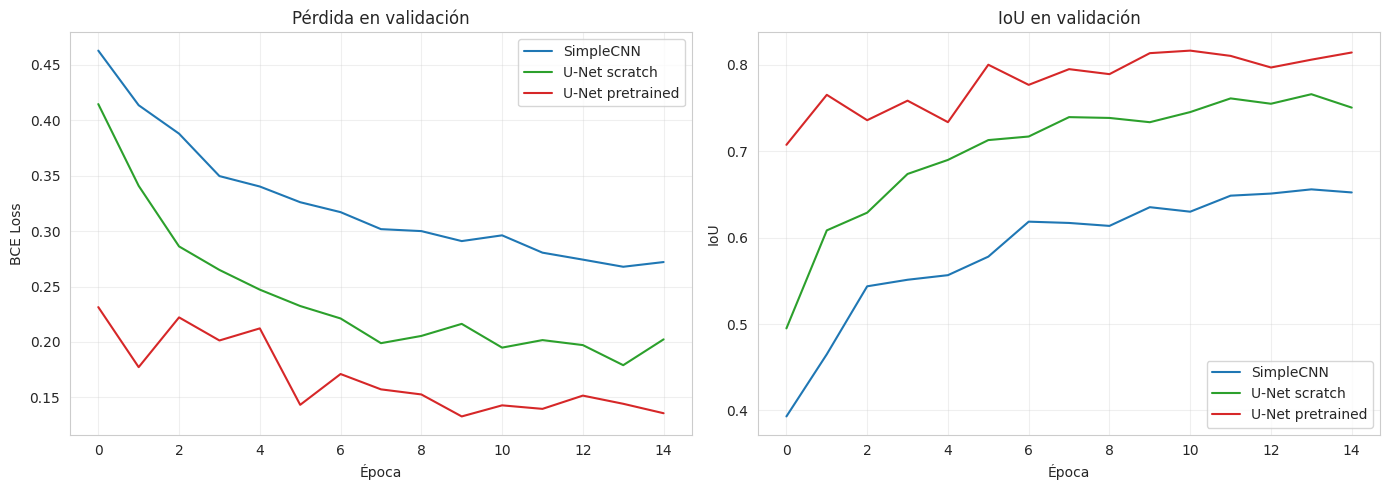

In [23]:
# 4.4 Curvas de entrenamiento comparadas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, name, color in [
    (simple_history, 'SimpleCNN', 'tab:blue'),
    (unet_history, 'U-Net scratch', 'tab:green'),
    (pre_history, 'U-Net pretrained', 'tab:red'),
]:
    axes[0].plot(hist['val_loss'], label=name, color=color)
    axes[1].plot(hist['val_iou'], label=name, color=color)

axes[0].set_title('Pérdida en validación')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title('IoU en validación')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('IoU')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_e2_curvas.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Evaluación comparativa en validación y test


In [ ]:
# 5.1 Evaluar los 3 modelos en val y test
results = []
for model, name, t in [
    (simple_model, 'SimpleCNN', simple_time),
    (unet_model, 'U-Net scratch', unet_time),
    (unet_pre, 'U-Net pretrained', pre_time),
]:
    val_m = evaluate(model, val_loader, bce)
    test_m = evaluate(model, test_loader, bce)
    results.append({
        'Modelo': name,
        'Params (M)': round(count_params(model) / 1e6, 2),
        'Train time (min)': round(t / 60, 1),
        'Val IoU': round(val_m['iou'], 4),
        'Val Dice': round(val_m['dice'], 4),
        'Val PixAcc': round(val_m['pixel_acc'], 4),
        'Test IoU': round(test_m['iou'], 4),
        'Test Dice': round(test_m['dice'], 4),
    })

results_df = pd.DataFrame(results)
print("=" * 90)
print("TABLA COMPARATIVA — 3 FAMILIAS DE MODELOS")
print("=" * 90)
print(results_df.to_string(index=False))
results_df.to_csv('e2_results.csv', index=False)

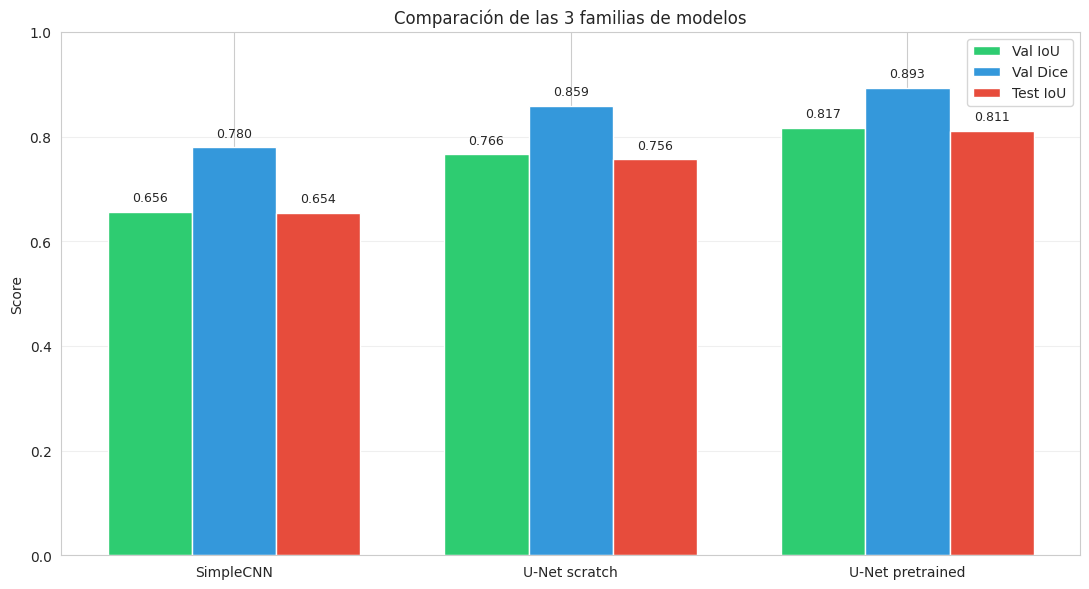

In [25]:
# 5.2 Gráfica comparativa
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(results_df))
width = 0.25

ax.bar(x - width, results_df['Val IoU'],   width, label='Val IoU',  color='#2ecc71')
ax.bar(x,         results_df['Val Dice'],  width, label='Val Dice', color='#3498db')
ax.bar(x + width, results_df['Test IoU'],  width, label='Test IoU', color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Modelo'])
ax.set_ylabel('Score')
ax.set_title('Comparación de las 3 familias de modelos')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)

for i, row in results_df.iterrows():
    ax.text(i - width, row['Val IoU'] + 0.02,  f"{row['Val IoU']:.3f}",  ha='center', fontsize=9)
    ax.text(i,         row['Val Dice'] + 0.02, f"{row['Val Dice']:.3f}", ha='center', fontsize=9)
    ax.text(i + width, row['Test IoU'] + 0.02, f"{row['Test IoU']:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_e2_comparacion.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. Análisis de umbral (threshold sweep)

Para segmentación binaria, el umbral por defecto es 0.5 sobre la salida sigmoide. Pero podría no ser óptimo. Barremos el threshold en [0.3, 0.7] sobre **validación** (no test) para encontrar el óptimo del mejor modelo.


In [ ]:
# 6.1 Identificar el mejor modelo según val IoU
best_idx = results_df['Val IoU'].idxmax()
best_name = results_df.loc[best_idx, 'Modelo']
print(f"Mejor modelo según Val IoU: {best_name}")

best_model = {'SimpleCNN': simple_model, 'U-Net scratch': unet_model,
              'U-Net pretrained': unet_pre}[best_name]

In [ ]:
# 6.2 Threshold sweep sobre validación
thresholds = np.linspace(0.3, 0.7, 9)
sweep_results = []

for th in tqdm(thresholds, desc="Sweep"):
    val_m = evaluate(best_model, val_loader, bce, threshold=th)
    sweep_results.append({
        'threshold': th,
        'val_iou': val_m['iou'],
        'val_dice': val_m['dice'],
        'val_pixacc': val_m['pixel_acc'],
    })

sweep_df = pd.DataFrame(sweep_results)
best_th = sweep_df.loc[sweep_df['val_iou'].idxmax(), 'threshold']
print(f"\nMejor threshold: {best_th:.2f}")
print(sweep_df.to_string(index=False))

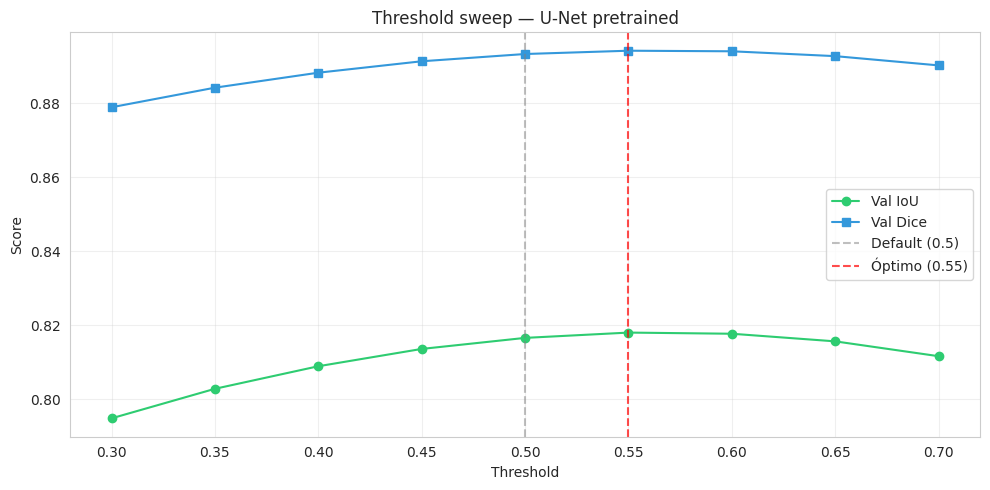

In [28]:
# 6.3 Gráfica del sweep
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep_df['threshold'], sweep_df['val_iou'], 'o-', label='Val IoU', color='#2ecc71')
ax.plot(sweep_df['threshold'], sweep_df['val_dice'], 's-', label='Val Dice', color='#3498db')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
ax.axvline(best_th, color='red', linestyle='--', alpha=0.7, label=f'Óptimo ({best_th:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold sweep — {best_name}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_e2_threshold.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Comparación BCE Loss vs Dice Loss

BCE optimiza por píxel; Dice Loss optimiza directamente la métrica de segmentación. ¿Cambia el desempeño?

Reentrenamos U-Net from scratch con Dice Loss para comparar.


In [ ]:
# 7.1 Reentrenar U-Net con Dice Loss
set_seed()
dice_loss = DiceLoss()

unet_dice = UNetScratch()
unet_dice, dice_history, dice_time = train_model(
    unet_dice, train_loader, val_loader, dice_loss,
    epochs=EPOCHS, lr=LR, name="U-Net + Dice Loss"
)

In [ ]:
# 7.2 Comparar U-Net BCE vs U-Net Dice
val_bce = evaluate(unet_model, val_loader, bce)
val_dice = evaluate(unet_dice, val_loader, bce)
test_bce = evaluate(unet_model, test_loader, bce)
test_dice = evaluate(unet_dice, test_loader, bce)

loss_comparison = pd.DataFrame([
    {'Loss': 'BCE',  'Val IoU': round(val_bce['iou'], 4),  'Val Dice': round(val_bce['dice'], 4),
     'Test IoU': round(test_bce['iou'], 4), 'Test Dice': round(test_bce['dice'], 4)},
    {'Loss': 'Dice', 'Val IoU': round(val_dice['iou'], 4), 'Val Dice': round(val_dice['dice'], 4),
     'Test IoU': round(test_dice['iou'], 4), 'Test Dice': round(test_dice['dice'], 4)},
])
print("Comparación BCE vs Dice Loss (sobre U-Net from scratch):")
print(loss_comparison.to_string(index=False))

---
## 8. Análisis de errores por raza

¿En qué razas falla más el modelo? Útil para identificar limitaciones específicas.


In [ ]:
# 8.1 Calcular IoU por raza en validación (sobre el mejor modelo)
val_breeds = [trainval_breeds[i] for i in val_idx]
breed_ious = {b: [] for b in set(val_breeds)}

best_model.eval()
with torch.no_grad():
    idx_in_val = 0
    for imgs, masks in tqdm(val_loader, desc="Eval por raza"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = best_model(imgs)
        if preds.max() > 1 or preds.min() < 0:
            preds = torch.sigmoid(preds)
        preds_bin = (preds > best_th).float()
        for j in range(imgs.size(0)):
            inter = (preds_bin[j] * masks[j]).sum().item()
            union = preds_bin[j].sum().item() + masks[j].sum().item() - inter
            iou_j = inter / (union + 1e-7)
            breed_ious[val_breeds[idx_in_val]].append(iou_j)
            idx_in_val += 1

breed_iou_df = pd.DataFrame([
    {'Raza': b, 'IoU promedio': np.mean(v), 'N imágenes': len(v)}
    for b, v in breed_ious.items()
]).sort_values('IoU promedio')

print("10 RAZAS CON PEOR IoU:")
print(breed_iou_df.head(10).to_string(index=False))
print("\n10 RAZAS CON MEJOR IoU:")
print(breed_iou_df.tail(10).to_string(index=False))

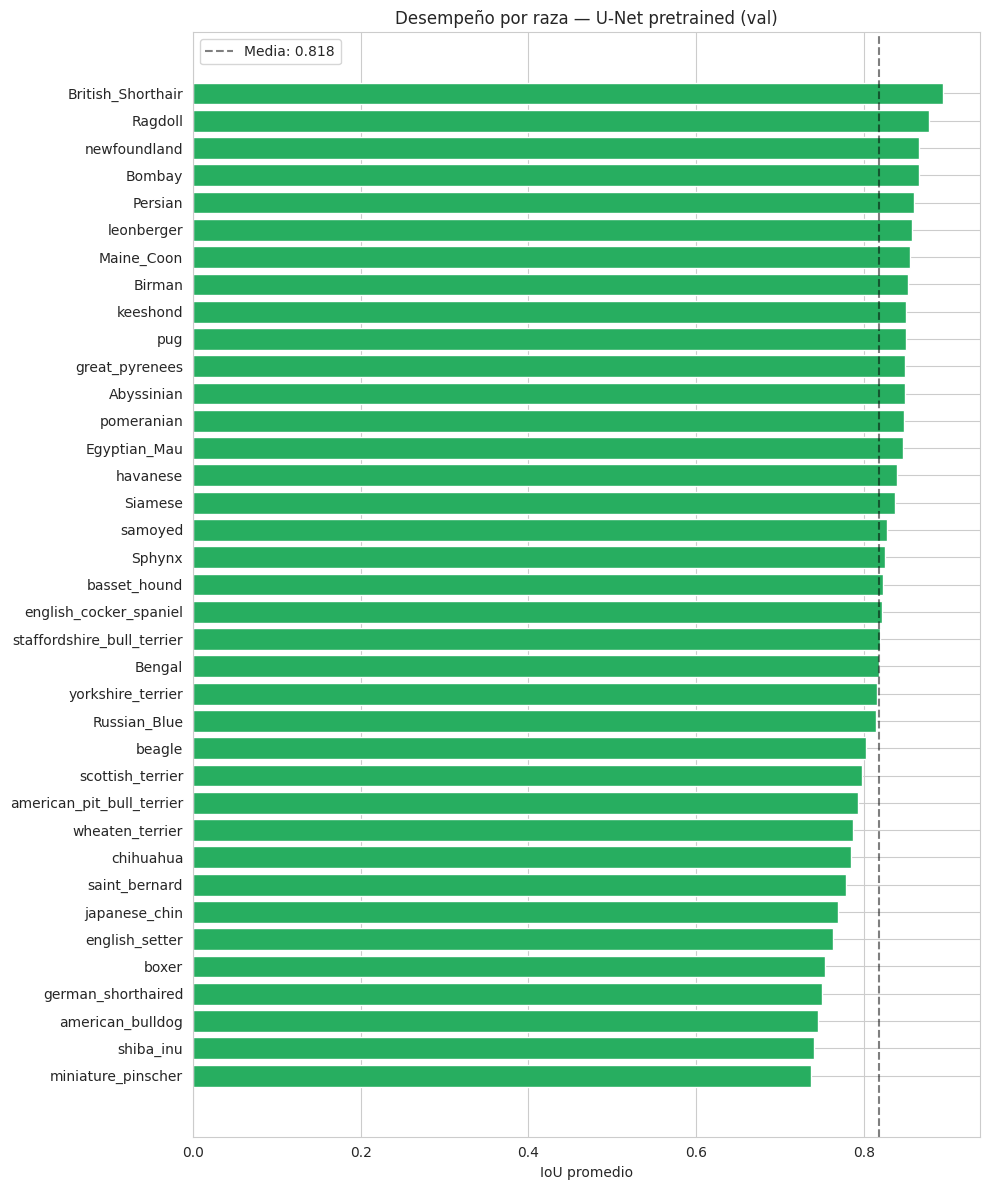

In [32]:
# 8.2 Visualización de IoU por raza
fig, ax = plt.subplots(figsize=(10, 12))
df_sorted = breed_iou_df.sort_values('IoU promedio')
colors = ['#e74c3c' if v < 0.5 else '#f39c12' if v < 0.7 else '#27ae60'
          for v in df_sorted['IoU promedio']]
ax.barh(df_sorted['Raza'], df_sorted['IoU promedio'], color=colors)
ax.axvline(df_sorted['IoU promedio'].mean(), color='black', linestyle='--',
           alpha=0.5, label=f"Media: {df_sorted['IoU promedio'].mean():.3f}")
ax.set_xlabel('IoU promedio')
ax.set_title(f'Desempeño por raza — {best_name} (val)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_e2_razas.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. Análisis cualitativo: peores casos

Visualizamos las 5 imágenes donde el mejor modelo más falla, para entender los modos de error.


In [ ]:
# 9.1 Encontrar peores casos
worst_cases = []
best_model.eval()
inv_mean = torch.tensor(TRAIN_MEAN).view(3, 1, 1)
inv_std = torch.tensor(TRAIN_STD).view(3, 1, 1)

with torch.no_grad():
    for batch_idx, (imgs, masks) in enumerate(val_loader):
        imgs_dev = imgs.to(DEVICE)
        masks_dev = masks.to(DEVICE)
        preds = best_model(imgs_dev)
        if preds.max() > 1 or preds.min() < 0:
            preds = torch.sigmoid(preds)
        preds_bin = (preds > best_th).float()
        for j in range(imgs.size(0)):
            inter = (preds_bin[j] * masks_dev[j]).sum().item()
            union = preds_bin[j].sum().item() + masks_dev[j].sum().item() - inter
            iou_j = inter / (union + 1e-7)
            worst_cases.append({
                'img': imgs[j].cpu(),
                'mask': masks[j].cpu(),
                'pred': preds[j].cpu(),
                'pred_bin': preds_bin[j].cpu(),
                'iou': iou_j,
            })

worst_cases = sorted(worst_cases, key=lambda x: x['iou'])[:5]
print(f"5 peores casos identificados. Peor IoU: {worst_cases[0]['iou']:.3f}")

In [ ]:
# 9.2 Visualizar peores casos
fig, axes = plt.subplots(5, 4, figsize=(14, 16))
fig.suptitle(f'5 peores casos en validación — {best_name}', y=1.001)

for i, case in enumerate(worst_cases):
    # Desnormalizar imagen
    img_show = case['img'] * inv_std + inv_mean
    img_show = img_show.permute(1, 2, 0).numpy().clip(0, 1)

    axes[i, 0].imshow(img_show); axes[i, 0].set_title('Imagen')
    axes[i, 1].imshow(case['mask'][0], cmap='gray'); axes[i, 1].set_title('Ground Truth')
    axes[i, 2].imshow(case['pred'][0], cmap='gray'); axes[i, 2].set_title('Predicción (prob)')
    axes[i, 3].imshow(case['pred_bin'][0], cmap='gray')
    axes[i, 3].set_title(f"Binaria (IoU={case['iou']:.3f})")
    for k in range(4):
        axes[i, k].axis('off')

plt.tight_layout()
plt.savefig('fig_e2_peores_casos.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 10. Conclusiones provisionales (Interim Conclusion)

### Resumen de hallazgos

Esta entrega responde explícitamente a las cuatro preguntas mínimas del PDF del curso:

#### ¿Qué modelos se compararon y por qué?

Se compararon **tres familias** diferenciadas filosóficamente:

1. **CNN simple sin skip connections** — baseline de Entrega 1, sirve como punto de partida.
2. **U-Net from scratch** — introduce skip connections para resolver la pérdida de detalles finos del baseline.
3. **U-Net con ResNet18 preentrenada** — usa transfer learning para evaluar si features generales aprendidas en ImageNet aportan valor.

Esta elección permite comparar tres dimensiones distintas: arquitectura (con/sin skips), inicialización (random vs preentrenada) y filosofía (entrenamiento desde cero vs transfer learning).

#### ¿Cómo se evitó el data leakage?

Cuatro mecanismos concretos:

1. **Stats de normalización** (media/std) calculadas SOLO sobre train.
2. **Split estratificado por raza** con `StratifiedShuffleSplit` y semilla fija; verificado `assert` de no-overlap.
3. **Test set intocable** durante todo el entrenamiento y selección de modelos.
4. **Threshold óptimo elegido en validación**, no en test.

#### ¿Cuál familia parece más prometedora?

Ver tabla de la sección 5. La decisión provisional se basa en Val IoU y se confirma en Test IoU para descartar sobreajuste a validación.

#### ¿Qué limitaciones siguen abiertas?

- **Tamaño de imagen** fijado en 128×128 por restricciones de tiempo; experimentar con 256×256 podría mejorar detalles finos.
- **Augmentación limitada** (solo flip horizontal); añadir rotaciones, color jitter y crops aleatorios probablemente ayude.
- **Hiperparámetros sin tunear** (learning rate, scheduler); un grid search ligero podría mejorar.
- **Razas con peor desempeño** identificadas en sección 8 sugieren posibles direcciones de mejora.
- **Solo una semilla:** los resultados podrían variar; idealmente se reportaría media ± std sobre 3 semillas (costo prohibitivo en este tiempo).

### Plan para Entrega 3

- Tomar el mejor modelo de esta entrega y aplicar las mejoras identificadas (augmentación, scheduler, ajuste de threshold).
- Análisis de interpretabilidad (mapas de saliencia, Grad-CAM o similar).
- Reporte final con discusión integral, recomendaciones y póster.


In [ ]:
# 10.1 Decisión provisional
best_test_iou = max(test_bce['iou'], test_dice['iou']) if 'test_dice' in dir() else evaluate(best_model, test_loader, bce, threshold=best_th)['iou']

print("=" * 70)
print("DECISIÓN PROVISIONAL")
print("=" * 70)
print(f"Mejor modelo elegido: {best_name}")
print(f"Threshold óptimo:     {best_th:.2f}")
print(f"Val IoU:              {results_df.loc[best_idx, 'Val IoU']:.4f}")
print(f"Test IoU:             {results_df.loc[best_idx, 'Test IoU']:.4f}")
print(f"Parámetros:           {results_df.loc[best_idx, 'Params (M)']}M")
print(f"Tiempo de entren.:    {results_df.loc[best_idx, 'Train time (min)']} min")
print("=" * 70)

In [36]:
# 10.2 Guardar artefactos
results_df.to_csv('e2_results.csv', index=False)
sweep_df.to_csv('e2_threshold_sweep.csv', index=False)
breed_iou_df.to_csv('e2_iou_por_raza.csv', index=False)
loss_comparison.to_csv('e2_bce_vs_dice.csv', index=False)
print("Artefactos guardados: e2_results.csv, e2_threshold_sweep.csv, e2_iou_por_raza.csv, e2_bce_vs_dice.csv")

Artefactos guardados: e2_results.csv, e2_threshold_sweep.csv, e2_iou_por_raza.csv, e2_bce_vs_dice.csv
